# MPX5700AP Pressure Sensor Calibration and Analysis

**Project**: Digital Pressure System Calibration  
**Hardware**: M5Stack Atom Lite + MPX5700AP Pressure Sensor  
**Sensor Range**: 15-700 kPa (absolute pressure)  
**ADC**: 12-bit (0-4095), ESP32

## Objectives
1. Determine resolution and range of the digital pressure system
2. Calibrate ADC readings to Pascal scale
3. Test linearity of pressure response
4. Calculate effective resolution based on noise analysis

## I. System Preparation and Resolution/Range Determination

### Theoretical Specifications
- **ADC Resolution**: 12-bit = 4096 levels (0-4095)
- **ADC Reference Voltage**: 3.3V
- **Sensor Range**: 15-700 kPa (MPX5700AP datasheet)
- **Sensor Output**: 0.2V - 4.7V (for 5V supply)
- **Transfer Function**: $V_{out} = V_S \times (0.0012858 \times P + 0.04)$

### Effective Resolution
Will be calculated after noise analysis in Section IV.

## II. Import Libraries and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
import serial
import time

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


### Function to Read Data from ESP32 via Serial

In [2]:
def read_pressure_from_esp32(port='COM3', baudrate=115200, num_readings=10, delay=0.5):
    """
    Read ADC values from ESP32 via serial connection.
    
    Parameters:
    - port: Serial port (e.g., 'COM3' on Windows, '/dev/ttyUSB0' on Linux)
    - baudrate: Communication speed (default 115200)
    - num_readings: Number of readings to collect
    - delay: Delay between readings in seconds
    
    Returns:
    - List of ADC values
    """
    adc_values = []
    
    try:
        # Open serial connection
        ser = serial.Serial(port, baudrate, timeout=2)
        time.sleep(2)  # Wait for connection to stabilize
        
        print(f"Connected to {port} at {baudrate} baud")
        print(f"Collecting {num_readings} readings...")
        
        # Clear buffer
        ser.reset_input_buffer()
        
        for i in range(num_readings):
            line = ser.readline().decode('utf-8').strip()
            
            # Parse ADC value from line (assuming format: "ADC: 1234" or just "1234")
            try:
                if ":" in line:
                    adc_value = int(line.split(":")[-1].strip())
                else:
                    adc_value = int(line)
                
                adc_values.append(adc_value)
                print(f"Reading {i+1}/{num_readings}: ADC = {adc_value}")
                
            except ValueError:
                print(f"Skipping invalid line: {line}")
                continue
            
            time.sleep(delay)
        
        ser.close()
        print(f"\\nCollected {len(adc_values)} valid readings")
        
    except serial.SerialException as e:
        print(f"Error: {e}")
        print("Make sure the ESP32 is connected and the correct port is specified.")
    
    return adc_values

# Example usage (commented out - uncomment when ready to collect data)
# adc_readings = read_pressure_from_esp32(port='COM3', num_readings=10)

## III. Data Collection Protocol

### Experiment Setup
- **Low Pressure**: 1ml syringe volume (10 measurements)
- **Medium Pressure**: 5ml syringe volume (10 measurements)
- **High Pressure**: 7ml syringe volume (10 measurements)
- **Total**: 30 measurements

### Instructions
1. Connect M5 Atom Lite to computer via USB
2. Upload the pressure reading sketch to ESP32
3. Open Serial Monitor to verify readings
4. For each pressure level:
   - Push syringe to specified volume
   - Wait for pressure to stabilize
   - Collect 10 ADC readings
   - Release pressure before next level

In [7]:
# Option 1: Collect data from ESP32 (uncomment when ready)
#print("=== Collecting 1ml pressure data ===")
#adc_1ml = read_pressure_from_esp32(port='COM3', num_readings=10)
# 
#print("\\n=== Collecting 5ml pressure data ===")
#adc_5ml = read_pressure_from_esp32(port='COM3', num_readings=10)
# 
print("\\n=== Collecting 7ml pressure data ===")
adc_7ml = read_pressure_from_esp32(port='COM3', num_readings=10)

# Option 2: Manual data entry (use this if collecting data separately)
# Replace these example values with your actual measurements
# adc_1ml = [1200, 1205, 1198, 1203, 1201, 1199, 1204, 1202, 1200, 1197]  # Example data
# adc_5ml = [2100, 2105, 2098, 2103, 2101, 2099, 2104, 2102, 2100, 2097]  # Example data
# adc_9ml = [3000, 3005, 2998, 3003, 3001, 2999, 3004, 3002, 3000, 2997]  # Example data

#print(f"1ml readings: {len(adc_1ml)} values")
#print(f"5ml readings: {len(adc_5ml)} values")
print(f"7ml readings: {len(adc_7ml)} values")

\n=== Collecting 7ml pressure data ===
Connected to COM3 at 115200 baud
Reading 1/10: ADC = 2007
Reading 2/10: ADC = 1978
Reading 3/10: ADC = 1968
Reading 4/10: ADC = 1967
Reading 5/10: ADC = 1933
Reading 6/10: ADC = 1942
Reading 7/10: ADC = 1936
Reading 8/10: ADC = 1919
Reading 9/10: ADC = 1940
Reading 10/10: ADC = 1934
\nCollected 10 valid readings
7ml readings: 10 values


### Create DataFrame with All Measurements

In [10]:
# Create DataFrame
data = {
    'volume_ml': [1]*len(adc_1ml) + [5]*len(adc_5ml) + [9]*len(adc_7ml),
    'adc_value': adc_1ml + adc_5ml + adc_7ml
}

df = pd.DataFrame(data)

# Add measurement number for each volume level
df['measurement_num'] = df.groupby('volume_ml').cumcount() + 1

print("Data Summary:")
print(df.groupby('volume_ml')['adc_value'].describe())
print(f"\\nTotal measurements: {len(df)}")
print("\\nFirst few rows:")
df.head()

Data Summary:
           count    mean        std     min     25%     50%      75%     max
volume_ml                                                                   
1           10.0   868.2  14.312388   834.0   863.0   871.0   875.00   883.0
5           10.0  1482.8  20.579386  1463.0  1470.5  1473.5  1497.75  1519.0
9           10.0  1952.4  26.779760  1919.0  1934.5  1941.0  1967.75  2007.0
\nTotal measurements: 30
\nFirst few rows:


,volume_ml,adc_value,measurement_num
0,1,875,1
1,1,869,2
2,1,883,3
3,1,883,4
4,1,834,5


## IV. Data Analysis and Calibration

### 1. Convert ADC to Voltage and Pressure (kPa)

In [ ]:
# ADC to Voltage conversion
V_ref = 3.3  # ESP32 ADC reference voltage
ADC_max = 4095  # 12-bit ADC

df['voltage'] = (df['adc_value'] / ADC_max) * V_ref

# MPX5700AP: Vout = Vs * (0.0012858 * P + 0.04)
# Rearranged: P = (Vout/Vs - 0.04) / 0.0012858
# For 3.3V ADC reference (sensor still powered at 5V typically):
# Simplified linear conversion for 15-700 kPa range
V_min = 0.2  # Voltage at 15 kPa
V_max = 4.7  # Voltage at 700 kPa (assuming 5V supply)
P_min = 15   # kPa
P_max = 700  # kPa

# Linear conversion (adjust if sensor has different supply voltage)
df['pressure_kpa'] = ((df['voltage'] - V_min) / (V_max - V_min)) * (P_max - P_min) + P_min

# Clamp to valid range. if pressures are too low or high, range (15-700kPa)
df['pressure_kpa'] = df['pressure_kpa'].clip(P_min, P_max)

print("Calibration applied!")
print("\\nPressure by volume level:")
print(df.groupby('volume_ml')['pressure_kpa'].agg(['mean', 'std', 'min', 'max']))
df.head()

Calibration applied!
\nPressure by volume level:
                 mean       std         min         max
volume_ml                                              
1           91.057582  1.755700   86.862271   92.873097
5          166.450517  2.524472  164.021652  170.891168
9          224.056313  3.285071  219.959137  230.754090


,volume_ml,adc_value,measurement_num,voltage,pressure_kpa
0,1,875,1,0.705128,91.891738
1,1,869,2,0.700293,91.155718
2,1,883,3,0.711575,92.873097
3,1,883,4,0.711575,92.873097
4,1,834,5,0.672088,86.862271


### 2. Visualization of Raw Data

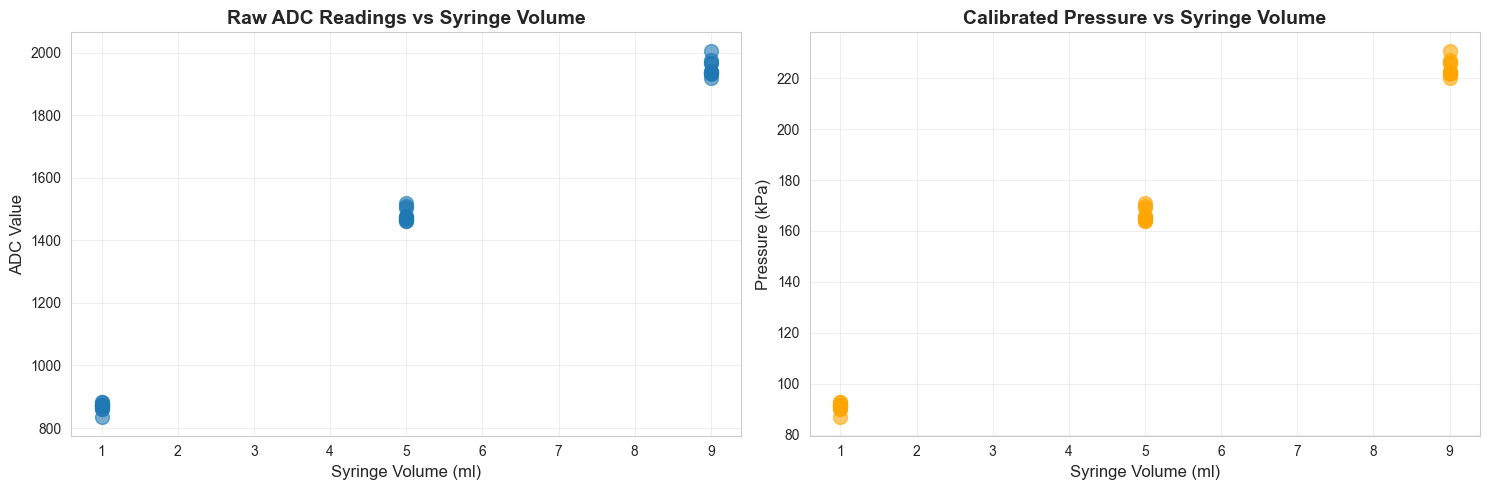

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: ADC values by volume
axes[0].scatter(df['volume_ml'], df['adc_value'], alpha=0.6, s=100)
axes[0].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0].set_ylabel('ADC Value', fontsize=12)
axes[0].set_title('Raw ADC Readings vs Syringe Volume', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Pressure values by volume
axes[1].scatter(df['volume_ml'], df['pressure_kpa'], alpha=0.6, s=100, color='orange')
axes[1].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[1].set_ylabel('Pressure (kPa)', fontsize=12)
axes[1].set_title('Calibrated Pressure vs Syringe Volume', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3. Linearity Test - Regression Analysis

In [13]:
# Perform linear regression
slope, intercept, r_value, p_value, std_err = stats.linregress(df['volume_ml'], df['pressure_kpa'])

# Calculate predicted values
df['pressure_predicted'] = slope * df['volume_ml'] + intercept

# Calculate residuals (errors)
df['residual'] = df['pressure_kpa'] - df['pressure_predicted']

print("=== Linear Regression Results ===")
print(f"Slope: {slope:.4f} kPa/ml")
print(f"Intercept: {intercept:.4f} kPa")
print(f"R² (coefficient of determination): {r_value**2:.6f}")
print(f"P-value: {p_value:.6e}")
print(f"Standard error: {std_err:.4f}")
print(f"\\nRegression equation: P = {slope:.4f} * V + {intercept:.4f}")

# Check linearity quality
if r_value**2 > 0.95:
    print("\\n✓ Excellent linearity (R² > 0.95)")
elif r_value**2 > 0.90:
    print("\\n✓ Good linearity (R² > 0.90)")
else:
    print("\\n⚠ Poor linearity (R² < 0.90) - consider non-linear model")

=== Linear Regression Results ===
Slope: 16.6248 kPa/ml
Intercept: 77.3973 kPa
R² (coefficient of determination): 0.992041
P-value: 6.134574e-31
Standard error: 0.2814
\nRegression equation: P = 16.6248 * V + 77.3973
\n✓ Excellent linearity (R² > 0.95)


### 4. Linearity Visualization with Regression Line

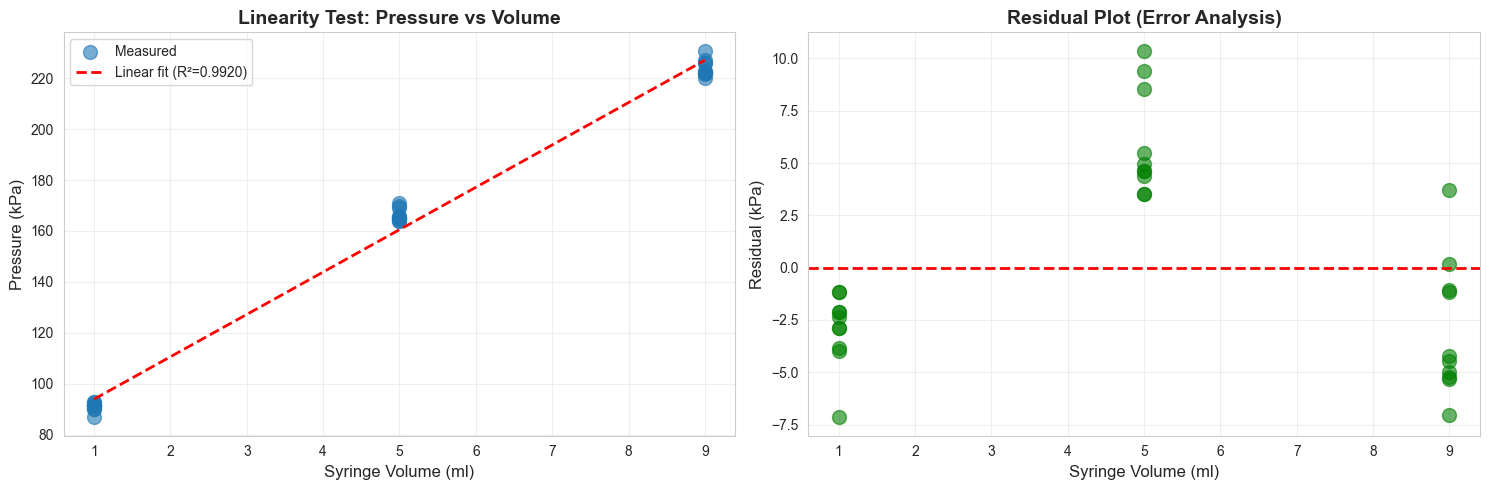

\nResidual Analysis:
Mean residual: -0.0000 kPa
Std deviation of residuals: 4.9464 kPa
Max absolute residual: 10.3697 kPa


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Scatter plot with regression line
axes[0].scatter(df['volume_ml'], df['pressure_kpa'], alpha=0.6, s=100, label='Measured')
x_line = np.linspace(df['volume_ml'].min(), df['volume_ml'].max(), 100)
y_line = slope * x_line + intercept
axes[0].plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear fit (R²={r_value**2:.4f})')
axes[0].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[0].set_ylabel('Pressure (kPa)', fontsize=12)
axes[0].set_title('Linearity Test: Pressure vs Volume', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual plot
axes[1].scatter(df['volume_ml'], df['residual'], alpha=0.6, s=100, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Syringe Volume (ml)', fontsize=12)
axes[1].set_ylabel('Residual (kPa)', fontsize=12)
axes[1].set_title('Residual Plot (Error Analysis)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\\nResidual Analysis:")
print(f"Mean residual: {df['residual'].mean():.4f} kPa")
print(f"Std deviation of residuals: {df['residual'].std():.4f} kPa")
print(f"Max absolute residual: {df['residual'].abs().max():.4f} kPa")

### 5. Resolution and Noise Analysis

In [15]:
# Use 5ml data for noise analysis (constant pressure)
df_5ml = df[df['volume_ml'] == 5].copy()

# Calculate noise metrics
noise_std_adc = df_5ml['adc_value'].std()
noise_std_kpa = df_5ml['pressure_kpa'].std()
noise_peak_to_peak_adc = df_5ml['adc_value'].max() - df_5ml['adc_value'].min()
noise_peak_to_peak_kpa = df_5ml['pressure_kpa'].max() - df_5ml['pressure_kpa'].min()

print("=== Noise Analysis (5ml constant pressure) ===")
print(f"\\nADC Noise:")
print(f"  Standard deviation: {noise_std_adc:.2f} counts")
print(f"  Peak-to-peak: {noise_peak_to_peak_adc:.2f} counts")
print(f"\\nPressure Noise:")
print(f"  Standard deviation: {noise_std_kpa:.4f} kPa")
print(f"  Peak-to-peak: {noise_peak_to_peak_kpa:.4f} kPa")

# Calculate effective resolution
# Theoretical resolution
theoretical_bits = 12
theoretical_levels = 2**theoretical_bits
print(f"\\n=== Resolution Analysis ===")
print(f"Theoretical ADC resolution: {theoretical_bits} bits ({theoretical_levels} levels)")

# Effective Number of Bits (ENOB)
# Method 1: Based on full scale range and noise
full_scale_adc = ADC_max
if noise_peak_to_peak_adc > 0:
    enob_1 = np.log2(full_scale_adc / noise_peak_to_peak_adc)
    print(f"\\nEffective resolution (Method 1 - peak-to-peak noise):")
    print(f"  ENOB: {enob_1:.2f} bits")
    print(f"  Effective levels: {2**enob_1:.0f}")

# Method 2: Based on SNR (Signal-to-Noise Ratio)
mean_signal_adc = df_5ml['adc_value'].mean()
if noise_std_adc > 0:
    snr = mean_signal_adc / noise_std_adc
    snr_db = 20 * np.log10(snr)
    enob_2 = (snr_db - 1.76) / 6.02
    print(f"\\nEffective resolution (Method 2 - SNR):")
    print(f"  SNR: {snr_db:.2f} dB")
    print(f"  ENOB: {enob_2:.2f} bits")
    print(f"  Effective levels: {2**enob_2:.0f}")

# Pressure resolution
pressure_resolution = noise_std_kpa
print(f"\\nPressure measurement resolution: ±{pressure_resolution:.4f} kPa")

=== Noise Analysis (5ml constant pressure) ===
\nADC Noise:
  Standard deviation: 20.58 counts
  Peak-to-peak: 56.00 counts
\nPressure Noise:
  Standard deviation: 2.5245 kPa
  Peak-to-peak: 6.8695 kPa
\n=== Resolution Analysis ===
Theoretical ADC resolution: 12 bits (4096 levels)
\nEffective resolution (Method 1 - peak-to-peak noise):
  ENOB: 6.19 bits
  Effective levels: 73
\nEffective resolution (Method 2 - SNR):
  SNR: 37.15 dB
  ENOB: 5.88 bits
  Effective levels: 59
\nPressure measurement resolution: ±2.5245 kPa


### 6. Noise Visualization

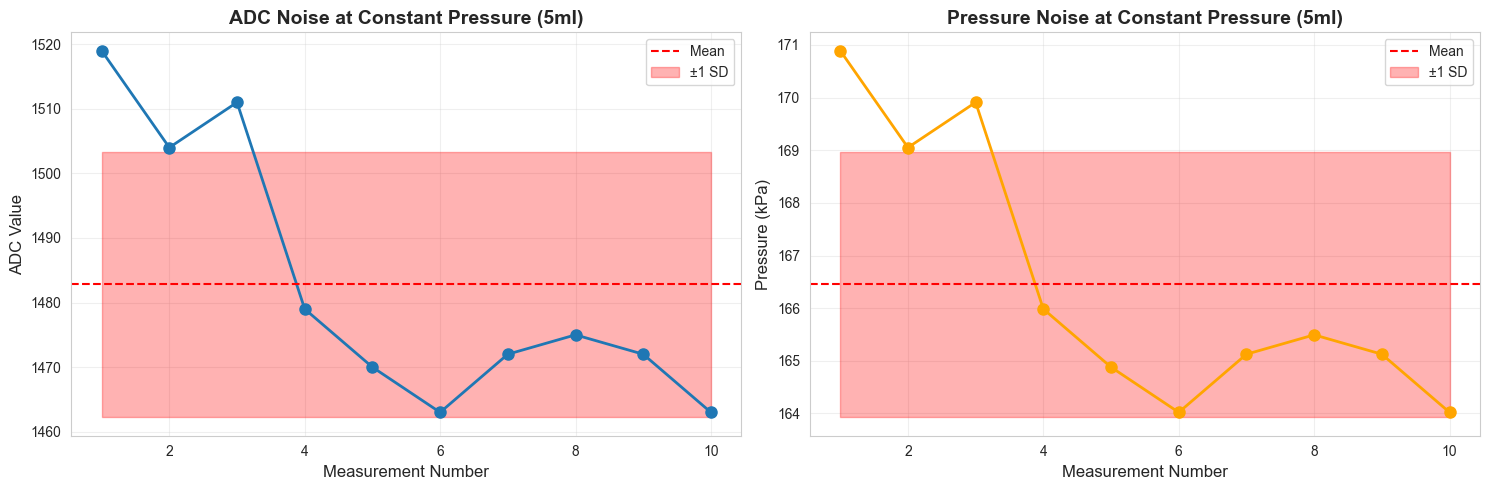

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: ADC noise over time
axes[0].plot(df_5ml['measurement_num'], df_5ml['adc_value'], 'o-', linewidth=2, markersize=8)
axes[0].axhline(y=df_5ml['adc_value'].mean(), color='r', linestyle='--', label='Mean')
axes[0].fill_between(df_5ml['measurement_num'], 
                      df_5ml['adc_value'].mean() - noise_std_adc,
                      df_5ml['adc_value'].mean() + noise_std_adc,
                      alpha=0.3, color='red', label='±1 SD')
axes[0].set_xlabel('Measurement Number', fontsize=12)
axes[0].set_ylabel('ADC Value', fontsize=12)
axes[0].set_title('ADC Noise at Constant Pressure (5ml)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Pressure noise over time
axes[1].plot(df_5ml['measurement_num'], df_5ml['pressure_kpa'], 'o-', linewidth=2, markersize=8, color='orange')
axes[1].axhline(y=df_5ml['pressure_kpa'].mean(), color='r', linestyle='--', label='Mean')
axes[1].fill_between(df_5ml['measurement_num'], 
                      df_5ml['pressure_kpa'].mean() - noise_std_kpa,
                      df_5ml['pressure_kpa'].mean() + noise_std_kpa,
                      alpha=0.3, color='red', label='±1 SD')
axes[1].set_xlabel('Measurement Number', fontsize=12)
axes[1].set_ylabel('Pressure (kPa)', fontsize=12)
axes[1].set_title('Pressure Noise at Constant Pressure (5ml)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## V. Summary Report

In [17]:
print("="*60)
print("  MPX5700AP PRESSURE SENSOR CALIBRATION REPORT")
print("="*60)

print("\\n1. SYSTEM SPECIFICATIONS")
print("-" * 60)
print(f"   Sensor: MPX5700AP")
print(f"   Sensor Range: {P_min}-{P_max} kPa")
print(f"   ADC: {theoretical_bits}-bit ({theoretical_levels} levels)")
print(f"   ADC Reference: {V_ref}V")

print("\\n2. CALIBRATION RESULTS")
print("-" * 60)
print(f"   Regression equation: P = {slope:.4f} * V + {intercept:.4f}")
print(f"   R² (linearity): {r_value**2:.6f}")
print(f"   Standard error: {std_err:.4f} kPa")

print("\\n3. PRESSURE MEASUREMENTS BY VOLUME")
print("-" * 60)
for vol in [1, 5, 9]:
    vol_data = df[df['volume_ml'] == vol]['pressure_kpa']
    print(f"   {vol}ml: {vol_data.mean():.2f} ± {vol_data.std():.2f} kPa")

print("\\n4. NOISE ANALYSIS (5ml constant pressure)")
print("-" * 60)
print(f"   ADC noise (SD): {noise_std_adc:.2f} counts")
print(f"   ADC noise (peak-to-peak): {noise_peak_to_peak_adc:.2f} counts")
print(f"   Pressure noise (SD): {noise_std_kpa:.4f} kPa")
print(f"   Pressure noise (peak-to-peak): {noise_peak_to_peak_kpa:.4f} kPa")

print("\\n5. EFFECTIVE RESOLUTION")
print("-" * 60)
if noise_peak_to_peak_adc > 0:
    print(f"   ENOB (peak-to-peak method): {enob_1:.2f} bits")
if noise_std_adc > 0:
    print(f"   ENOB (SNR method): {enob_2:.2f} bits")
    print(f"   SNR: {snr_db:.2f} dB")
print(f"   Pressure resolution: ±{pressure_resolution:.4f} kPa")

print("\\n6. LINEARITY ASSESSMENT")
print("-" * 60)
if r_value**2 > 0.95:
    print("   ✓ EXCELLENT - System shows excellent linearity")
elif r_value**2 > 0.90:
    print("   ✓ GOOD - System shows good linearity")
else:
    print("   ⚠ POOR - System shows poor linearity, consider non-linear correction")

print("\\n" + "="*60)

  MPX5700AP PRESSURE SENSOR CALIBRATION REPORT
\n1. SYSTEM SPECIFICATIONS
------------------------------------------------------------
   Sensor: MPX5700AP
   Sensor Range: 15-700 kPa
   ADC: 12-bit (4096 levels)
   ADC Reference: 3.3V
\n2. CALIBRATION RESULTS
------------------------------------------------------------
   Regression equation: P = 16.6248 * V + 77.3973
   R² (linearity): 0.992041
   Standard error: 0.2814 kPa
\n3. PRESSURE MEASUREMENTS BY VOLUME
------------------------------------------------------------
   1ml: 91.06 ± 1.76 kPa
   5ml: 166.45 ± 2.52 kPa
   9ml: 224.06 ± 3.29 kPa
\n4. NOISE ANALYSIS (5ml constant pressure)
------------------------------------------------------------
   ADC noise (SD): 20.58 counts
   ADC noise (peak-to-peak): 56.00 counts
   Pressure noise (SD): 2.5245 kPa
   Pressure noise (peak-to-peak): 6.8695 kPa
\n5. EFFECTIVE RESOLUTION
------------------------------------------------------------
   ENOB (peak-to-peak method): 6.19 bits
   ENOB 

## VI. Export Results

Save the analysis results and visualizations for documentation.

In [18]:
# Save DataFrame to CSV
df.to_csv('pressure_calibration_data.csv', index=False)
print("✓ Data saved to 'pressure_calibration_data.csv'")

# Save summary statistics
summary = {
    'slope_kpa_per_ml': slope,
    'intercept_kpa': intercept,
    'r_squared': r_value**2,
    'noise_std_adc': noise_std_adc,
    'noise_std_kpa': noise_std_kpa,
    'enob_peak_to_peak': enob_1 if noise_peak_to_peak_adc > 0 else None,
    'enob_snr': enob_2 if noise_std_adc > 0 else None,
    'pressure_resolution_kpa': pressure_resolution
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('calibration_summary.csv', index=False)
print("✓ Summary saved to 'calibration_summary.csv'")

✓ Data saved to 'pressure_calibration_data.csv'
✓ Summary saved to 'calibration_summary.csv'
